# Mall Customer Analysis

Importing Libraries

In [135]:
import pandas as pd                 #For data manipulation
import numpy as np                  #For numerical operations
import matplotlib.pyplot as plt     #For data visualization
import seaborn as sns               #For advanced visualizations
from sklearn.preprocessing import StandardScaler  #For feature scaling
from sklearn.cluster import KMeans               #For clustering analysis

Loading the dataset & Preliminary analysis to check the data

In [136]:
#Load the dataset
data = pd.read_csv("Mall_Customers.csv")

#Display the shape of the dataset
print("Number of rows and columns:", data.shape)

#Display the first 5 rows
print("\nTop 5 rows of the dataset:")
print(data.head())

#Check for missing values
print("\nMissing values in each column:")
print(data.isnull().sum())


Number of rows and columns: (200, 5)

Top 5 rows of the dataset:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing values in each column:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [137]:
#Display general information
print("Dataset Information:")
print(data.info())

#Display unique values in categorical columns
print("\nUnique values in categorical columns:")
for col in data.select_dtypes(include='object').columns:
    print(f"{col}: {data[col].unique()}")


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Unique values in categorical columns:
Genre: ['Male' 'Female']


Exploratory Data Analysis (EDA)

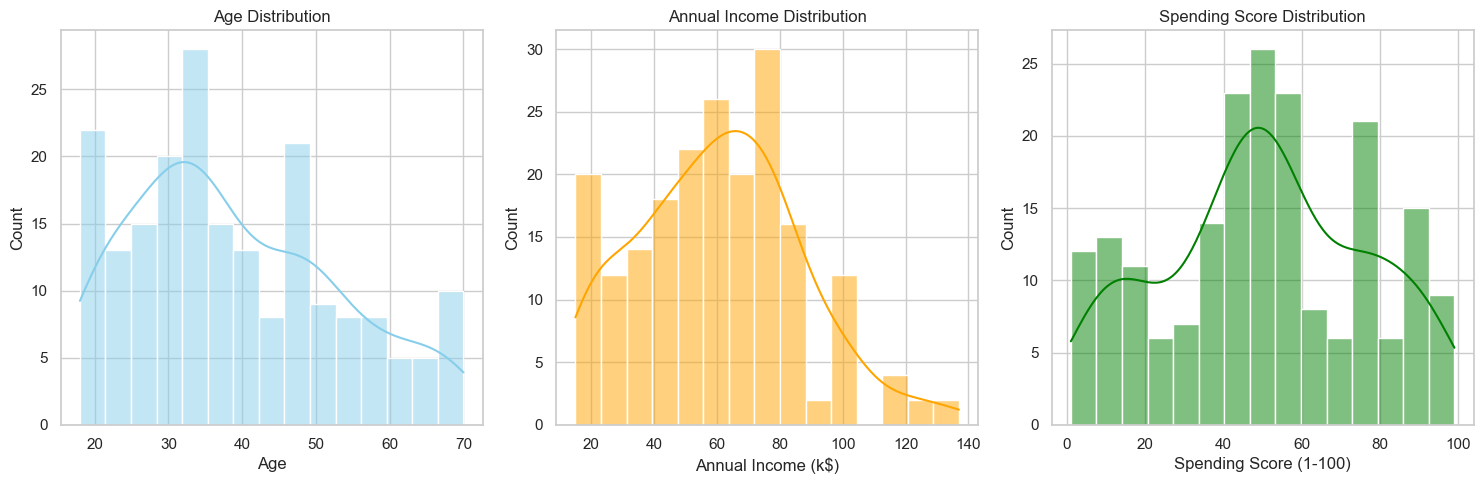

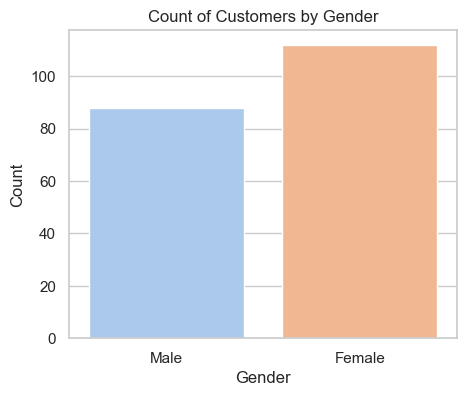

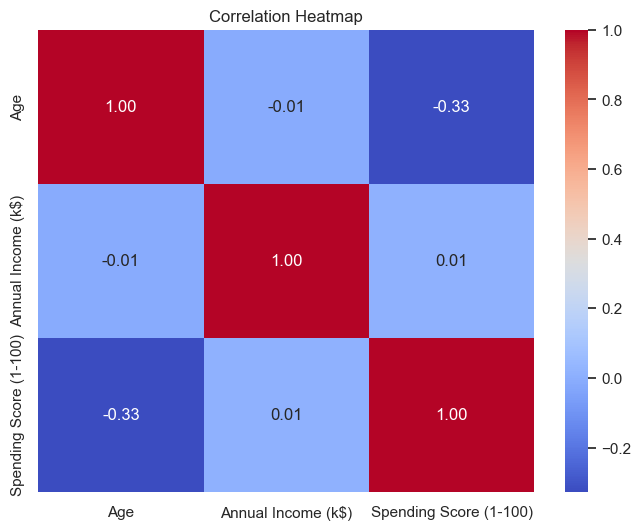

In [138]:
sns.set(style="whitegrid", palette="muted")

#Distribution of numerical features
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(data['Age'], bins=15, kde=True, color='skyblue')
plt.title('Age Distribution')

plt.subplot(1, 3, 2)
sns.histplot(data['Annual Income (k$)'], bins=15, kde=True, color='orange')
plt.title('Annual Income Distribution')

plt.subplot(1, 3, 3)
sns.histplot(data['Spending Score (1-100)'], bins=15, kde=True, color='green')
plt.title('Spending Score Distribution')

plt.tight_layout()
plt.show()

#Countplot for Gender
plt.figure(figsize=(5,4))
sns.countplot(x='Genre', data=data, hue='Genre', legend=False, palette='pastel')
plt.title('Count of Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

#Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


Outlier detection and removal (Using IQR Method)

In [139]:
#Numeric columns to check for outliers
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

#Calculate Q1, Q3, and IQR
Q1 = data[numeric_cols].quantile(0.25)
Q3 = data[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

#Determine which rows are outliers
outlier_mask = ((data[numeric_cols] < (Q1 - 1.5 * IQR)) | 
                (data[numeric_cols] > (Q3 + 1.5 * IQR)))

#Count outliers per column
outlier_counts = outlier_mask.sum()

print("Outlier count per column:")
print(outlier_counts)

Outlier count per column:
Age                       0
Annual Income (k$)        2
Spending Score (1-100)    0
dtype: int64


In [140]:
#Numeric columns to check
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

#Compute IQR for each numeric column
Q1 = data[numeric_cols].quantile(0.25)
Q3 = data[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

#Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Filter data: keep only rows within the bounds
data = data[~((data[numeric_cols] < lower_bound) | (data[numeric_cols] > upper_bound)).any(axis=1)].reset_index(drop=True)

print("Outliers removed successfully!")
print(f"New dataset shape: {data.shape}")


Outliers removed successfully!
New dataset shape: (198, 5)


Feature Engineering (One Hot Encoding & Scaling)

In [141]:
#One Hot Encoding
data_encoded = pd.get_dummies(data, columns=['Genre'], drop_first=True)

In [142]:
#Scale the relevant features for clustering
from sklearn.preprocessing import StandardScaler

X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Elbow method & Silhoutte Analysis to find optimal K

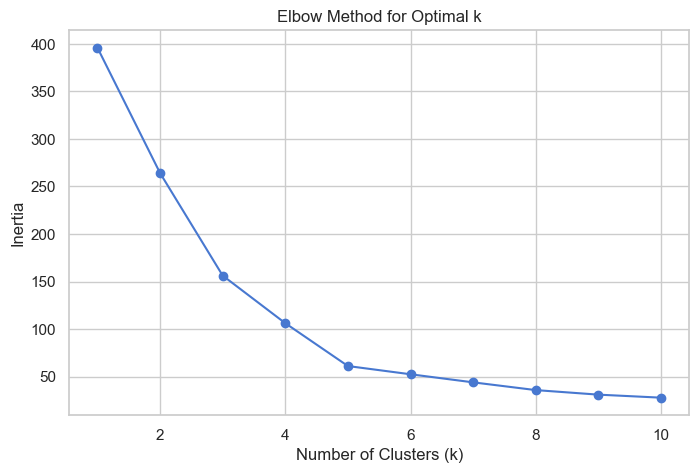

In [143]:
#Elbow Method to determine optimal k
import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#Scale the relevant features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

Optimal K = 5

K-Means Clustering & Visualisation

In [144]:
#K-means Clustering
from sklearn.cluster import KMeans

best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(X_scaled)

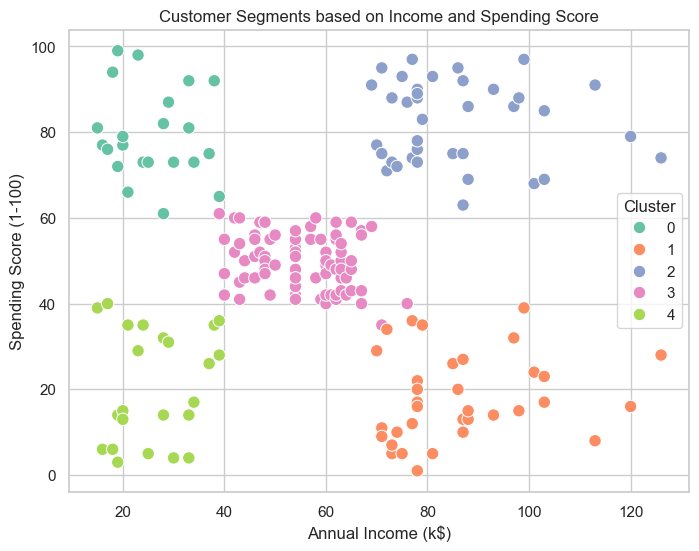

In [145]:
#Visualisation of clusters based on Income & Spending score
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    palette='Set2', 
    data=data, 
    s=80
)
plt.title('Customer Segments based on Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()


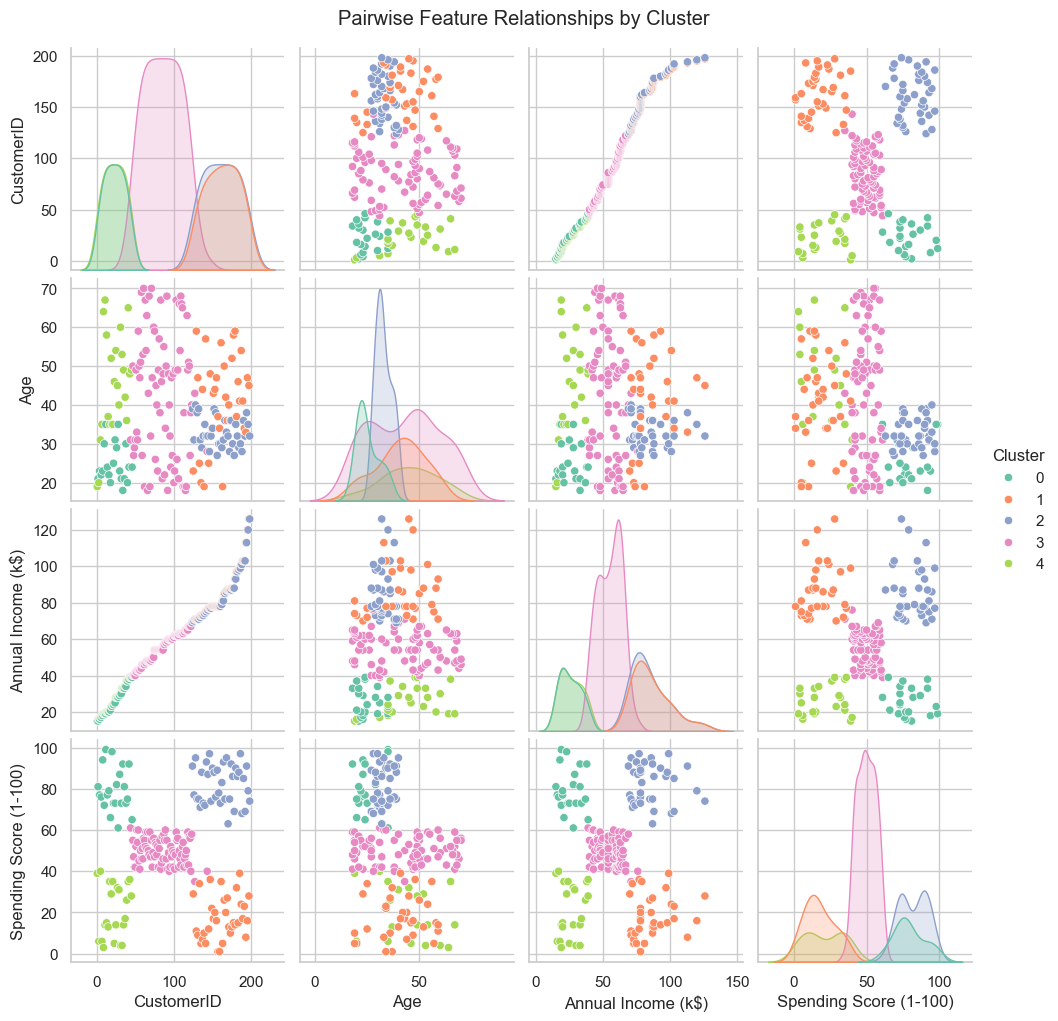

In [146]:
#Pairplot for feature relationships
sns.pairplot(data, hue='Cluster', palette='Set2', diag_kind='kde')
plt.suptitle('Pairwise Feature Relationships by Cluster', y=1.02)
plt.show()


Evaluation Metrics

In [147]:
#Silhouette Score Calculation
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, data['Cluster'])
print(f"Silhouette Score: {sil_score:.3f}")


Silhouette Score: 0.560


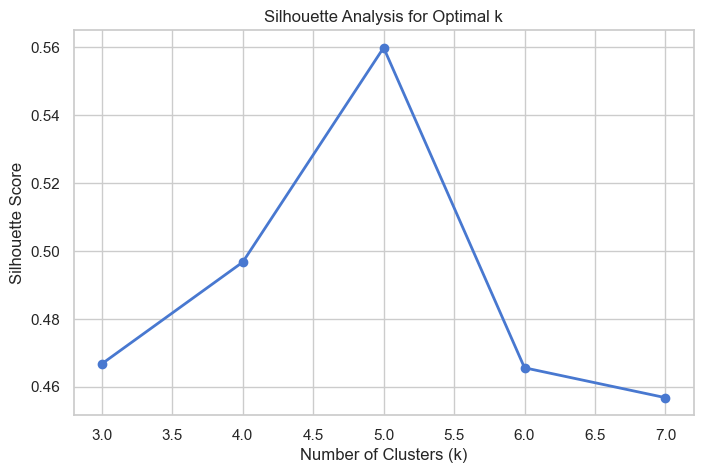

In [148]:
#Silhouette Analysis
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []
K = range(3, 8)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, 'bo-', linewidth=2)
plt.title('Silhouette Analysis for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

In [149]:
#Inertia 
inertia = kmeans.inertia_
print(f"Inertia for k={best_k}: {inertia:.2f}")

Inertia for k=5: 43.93
